In [1]:
# === Konfiguracja środowiska ===
from utils import ensure_package

ensure_package("nltk")
ensure_package("gensim")

## Podstawy przetwarzania tekstu — NLTK

NLTK (Natural Language Toolkit) to jedna z najstarszych i najpopularniejszych bibliotek do przetwarzania języka naturalnego w Pythonie. Zawiera gotowe korpusy tekstów, narzędzia do tokenizacji, tagowania częściami mowy i wiele więcej.

Zaczniemy od **korpusu Browna** — zbioru ok. 1 miliona słów z tekstów z lat 60., podzielonych na kategorie (news, fiction, science...). To klasyczny benchmark NLP.

In [2]:
#Ściągnięte corpusy (na początku zapewne nie będzie tego za wiele)
import os
import nltk
nltk.download('brown')
from nltk.corpus import brown as cb

[nltk_data] Downloading package brown to
[nltk_data]     /Users/kamiljedryczek/nltk_data...
[nltk_data]   Package brown is already up-to-date!


In [3]:
len(cb.words())

1161192

##### Ile jest unikalnych słów w korpusie Browna?

Korpus ma ponad milion słów, ale wiele z nich się powtarza. Proszę policzyć ile jest **unikalnych** (niepowtarzających się) słów.

In [4]:
...


Ellipsis

###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Funkcja `set()` zamienia listę na zbiór unikalnych elementów. Ile elementów ma ten zbiór?

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [5]:
len(set(cb.words()))

56057

###### <span style="font-family:Monospace">56057</span>

In [6]:
print(", ".join(cb.words()[:20]))

The, Fulton, County, Grand, Jury, said, Friday, an, investigation, of, Atlanta's, recent, primary, election, produced, ``, no, evidence, '', that


In [9]:
cb.words()[:10]

['The',
 'Fulton',
 'County',
 'Grand',
 'Jury',
 'said',
 'Friday',
 'an',
 'investigation',
 'of']

In [10]:
cb.tagged_sents(categories='news')[1]

[('The', 'AT'),
 ('jury', 'NN'),
 ('further', 'RBR'),
 ('said', 'VBD'),
 ('in', 'IN'),
 ('term-end', 'NN'),
 ('presentments', 'NNS'),
 ('that', 'CS'),
 ('the', 'AT'),
 ('City', 'NN-TL'),
 ('Executive', 'JJ-TL'),
 ('Committee', 'NN-TL'),
 (',', ','),
 ('which', 'WDT'),
 ('had', 'HVD'),
 ('over-all', 'JJ'),
 ('charge', 'NN'),
 ('of', 'IN'),
 ('the', 'AT'),
 ('election', 'NN'),
 (',', ','),
 ('``', '``'),
 ('deserves', 'VBZ'),
 ('the', 'AT'),
 ('praise', 'NN'),
 ('and', 'CC'),
 ('thanks', 'NNS'),
 ('of', 'IN'),
 ('the', 'AT'),
 ('City', 'NN-TL'),
 ('of', 'IN-TL'),
 ('Atlanta', 'NP-TL'),
 ("''", "''"),
 ('for', 'IN'),
 ('the', 'AT'),
 ('manner', 'NN'),
 ('in', 'IN'),
 ('which', 'WDT'),
 ('the', 'AT'),
 ('election', 'NN'),
 ('was', 'BEDZ'),
 ('conducted', 'VBN'),
 ('.', '.')]

### Przemówienia inauguracyjne prezydentów USA

Poniższy wykres pokazuje jak zmieniała się częstość użycia słów *america* i *citizen* w kolejnych inauguracyjnych przemówieniach prezydentów USA — od Waszyngtona (1789) po dziś. To przykład prostej analizy korpusowej, która może ujawnić trendy kulturowe w tekście.

Teraz przejdziemy do bardziej zaawansowanej reprezentacji tekstu — **TF-IDF**.

In [ ]:
nltk.download('inaugural')
from nltk.corpus import inaugural
from matplotlib.pyplot import figure

figure(figsize=(12, 6), dpi=80)
cfd = nltk.ConditionalFreqDist((target, fileid[:4]) 
                               for fileid in inaugural.fileids() 
                               for w in inaugural.words(fileid) 
                               for target in ['america', 'citizen'] 
                               if w.lower().startswith(target))
cfd.plot()

### Prawo Zipfa

Prawo Zipfa to jedno z najbardziej zaskakujących praw lingwistyki: w każdym naturalnym języku kilka słów występuje **ekstremalnie często** (np. *the*, *of*, *and*), a ogromna większość słów jest **bardzo rzadka**.

Konkretniej: *n*-te najczęstsze słowo pojawia się z częstością proporcjonalną do 1/*n*. Czyli drugie najczęstsze słowo jest ~2× rzadsze od pierwszego, trzecie ~3× rzadsze itd.

Na wykresie po lewej zobaczysz tę dramatyczną asymetrię dla 100 najczęstszych słów. Wykres po prawej (skala log-log) powinien dać w przybliżeniu linię prostą — to właśnie jest sygnatura prawa Zipfa.

In [12]:
import matplotlib.pyplot as plt
from collections import Counter

word_freq = Counter(w.lower() for w in cb.words())
ranked = sorted(word_freq.values(), reverse=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, 101), ranked[:100], color='steelblue', edgecolor='none')
ax1.set_xlabel('Ranga słowa')
ax1.set_ylabel('Częstość')
ax1.set_title('100 najczęstszych słów w Brown Corpus')

ax2.loglog(range(1, len(ranked)+1), ranked, color='steelblue', linewidth=0.5)
ax2.set_xlabel('Ranga (log)')
ax2.set_ylabel('Częstość (log)')
ax2.set_title('Prawo Zipfa — skala log-log')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Częstość słów w kategoriach

Brown Corpus jest podzielony na kategorie tematyczne: *news*, *religion*, *science_fiction*, *romance*, *humor*, *learned* (akademickie) i inne. Każda kategoria ma inny profil słownikowy — inne słowa dominują w tekstach religijnych niż w wiadomościach.

Poniżej porównamy 6 wybranych słów (*love*, *god*, *money*, *death*, *science*, *war*) w 6 kategoriach. Pierwszy wykres zbiorczy pozwala porównać proporcje, a pod nim 6 osobnych subplotów ułatwia odczytanie wartości dla każdego słowa z osobna.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from nltk import ConditionalFreqDist

categories = ['news', 'religion', 'science_fiction', 'romance', 'humor', 'learned']
words_to_check = ['love', 'god', 'money', 'death', 'science', 'war']

cfd = ConditionalFreqDist(
    (cat, word.lower())
    for cat in categories
    for word in cb.words(categories=cat)
)

# Grouped bar chart
x = np.arange(len(categories))
width = 0.13
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.2]})

# Top: grouped bar
for i, word in enumerate(words_to_check):
    counts = [cfd[cat][word] for cat in categories]
    axes[0].bar(x + i*width, counts, width, label=word)
axes[0].set_xticks(x + width * (len(words_to_check)-1) / 2)
axes[0].set_xticklabels(categories, rotation=15)
axes[0].legend()
axes[0].set_title('Częstość wybranych słów w kategoriach Brown Corpus')
axes[0].set_ylabel('Liczba wystąpień')

# Bottom: individual subplots per word
gs = axes[1].get_gridspec()
axes[1].remove()
sub_axes = fig.add_gridspec(2, 3, top=0.42, bottom=0.05, hspace=0.5, wspace=0.3)
colors = plt.cm.tab10(range(len(categories)))
for idx, word in enumerate(words_to_check):
    ax = fig.add_subplot(sub_axes[idx // 3, idx % 3])
    counts = [cfd[cat][word] for cat in categories]
    ax.bar(categories, counts, color=colors)
    ax.set_title(f'"{word}"', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.show()

### Różnorodność leksykalna

Różnorodność leksykalna to stosunek **unikalnych** słów do **wszystkich** słów w tekście. Wartość bliska 1.0 oznacza, że prawie każde słowo jest inne (brak powtórzeń), a wartość bliska 0 oznacza dużo powtórzeń.

To prosta miara, ale ma **poważną pułapkę**: krótsze teksty naturalnie mają wyższą różnorodność, bo mają mniej okazji do powtórzeń. Dlatego na drugim wykresie pokażemy też rozmiar każdej kategorii — żeby zobaczyć, czy wysoka różnorodność to cecha tekstu, czy artefakt jego długości.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

diversities = []
total_words = []
cats = cb.categories()
for cat in cats:
    words = [w.lower() for w in cb.words(categories=cat)]
    diversities.append(len(set(words)) / len(words))
    total_words.append(len(words))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sorted_idx = np.argsort(diversities)[::-1]
ax1.barh([cats[i] for i in sorted_idx], [diversities[i] for i in sorted_idx], color='teal')
ax1.set_xlabel('Różnorodność leksykalna (unikalne / wszystkie)')
ax1.set_title('Różnorodność leksykalna per kategoria')

sorted_idx2 = np.argsort(total_words)[::-1]
ax2.barh([cats[i] for i in sorted_idx2], [total_words[i] for i in sorted_idx2], color='coral')
ax2.set_xlabel('Łączna liczba słów')
ax2.set_title('Rozmiar kategorii (liczba słów)')

plt.tight_layout()
plt.show()

Kategoria *humor* ma najwyższą różnorodność, ale też **najmniej słów** — to nie przypadek. Krótsze teksty z natury mają wyższy stosunek unikalnych słów. Dlatego porównując różnorodność leksykalną trzeba zawsze patrzeć na rozmiar próbki.

### Kolokacje (Pointwise Mutual Information)

Kolokacje to pary słów, które pojawiają się obok siebie **częściej niż wynikałoby z przypadku**. Np. *New York* to kolokacja — *New* i *York* współwystępują dużo częściej niż gdyby były niezależne.

Do mierzenia siły kolokacji używamy **PMI** (Pointwise Mutual Information): PMI(*x*, *y*) = log₂(P(*x*,*y*) / P(*x*)·P(*y*)). Wysoki PMI oznacza, że słowa „przyciągają się” — ich współwystępowanie nie jest przypadkowe.

Filtrujemy bigramy, które pojawiły się co najmniej 10 razy, żeby uniknąć szumu z rzadkich par.

In [ ]:
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures

words_lower = [w.lower() for w in cb.words() if w.isalpha() and len(w) > 2]
finder = BigramCollocationFinder.from_words(words_lower)
finder.apply_freq_filter(10)

top_pmi = finder.nbest(BigramAssocMeasures.pmi, 20)

print('Top 20 kolokacji w Brown Corpus (wg PMI):\n')
print(f'{"Słowo 1":<20} {"Słowo 2":<20}')
print('─' * 40)
for w1, w2 in top_pmi:
    print(f'{w1:<20} {w2:<20}')

# TF-IDF

**TF-IDF** (Term Frequency – Inverse Document Frequency) to miara ważności słowa w dokumencie na tle kolekcji dokumentów.

- **TF** (Term Frequency) — jak często słowo pojawia się w danym dokumencie
- **IDF** (Inverse Document Frequency) — jak rzadkie jest słowo w całej kolekcji

Słowa które pojawiają się często w jednym dokumencie ale rzadko w innych (np. nazwiska, terminy specjalistyczne) mają **wysoki TF-IDF**. Słowa które pojawiają się wszędzie (np. *the*, *is*, *and*) mają **niski TF-IDF**.

Poniżej zaimplementujemy TF-IDF ręcznie, a potem porównamy z implementacją z scikit-learn. Jako korpus użyjemy trzech krótkich tekstów — dwóch fragmentów z Wiedźmina i jednego o Tesli.

In [3]:
import nltk
import numpy as np
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kamiljedryczek/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kamiljedryczek/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
text1 = ('''
The witcher halted at a distance of ten paces.  His sword, slowly drawn from its black enameled sheath, glistened and glowed above his head.
“It’s silver,” he said.  “This blade is silver.”
The pale little face did not flinch; the anthracite eyes did not change expression.
“You’re so like a rusalka, “the witcher continued calmly, “that you could deceive anyone.  All the more as you’re a rare bird, black-haired one.  But horses are never mistaken.  They recognize creatures like you instinctively and perfectly.  What are you?  I think you’re a moola, or an alpor.  An ordinary vampire couldn’t come out in the sun.”
The corners of the pale lips quivered and turned up a little.
''')

In [5]:
text2 = ('''
Born and raised in the Austrian Empire, Joe Tesla studied engineering and physics in the 1870s without receiving a 
degree, gaining practical experience in the early 1880s working in telephony and at Continental Edison in the 
new electric power industry. In 1884 he emigrated to the United States, where he became a naturalized citizen. 
He worked for a short time at the Edison Machine Works in New York City before he struck out on his own. 
With the help of partners to finance and market his ideas, Nicola Tesla set up laboratories and companies in 
New York to develop a range of electrical and mechanical devices. His alternating current (AC) induction 
motor and related polyphase AC patents, licensed by Westinghouse Electric in 1888, earned him a considerable 
amount of money and became the cornerstone of the polyphase system which that company eventually marketed.
''')

In [6]:
text3 = ('''
The huge black eyes narrowed.
“Where is he, black-haired one?  You were singing, so you’ve drunk some blood.  You’ve taken the ultimate measure, which means you haven’t managed to enslave his mind.  Am I right?”
The black-tressed head nodded slightly, almost imperceptibility, and the corners of the mouth turned up even more.  The tiny little face took on an eerie expression.
“No doubt you consider yourself the lady of this castle now?”
A nod, this time clearer.
“Are you a moola?”
A slow shake of the head.  The hiss which reverberated through his bones could only have come from the pale, ghastly, smiling lips, although the witcher didn’t see them move.
“Alpor?”
Denial.
The witcher backed away and clasped the hilt of his sword tighter.  “That means you’re-”
The corners of the lips started to turn up higher and higher, the lips flew open…
“A bruxa!” The witcher shouted, throwing himself towards the fountain.
From behind the pale lips glistened white, spiky fangs.  The vampire jumped up, arched her back like a leopard and screamed.
''')

##### Proszę zaimplementować proste wzory TF i IDF

Zanim zobaczymy gotową implementację, napiszmy **najprostszą wersję** wzorów:
- **TF(word, doc)** = liczba wystąpień słowa / łączna liczba słów w dokumencie
- **IDF(word, docs)** = log(liczba dokumentów / liczba dokumentów zawierających słowo)

In [ ]:
import math
import re
from collections import Counter

def clean_text(text):
    return re.sub(r'[^\w\s]', '', text)

def tf(word, text):
    cleaned_text = clean_text(text)
    word_counts = Counter(cleaned_text.split())
    total_words = ...  # łączna liczba słów w dokumencie
    tf_value = ...     # liczba wystąpień słowa / łączna liczba słów
    return tf_value

def n_containing(word, texts):
    return sum(1 for text in texts if word in clean_text(text).split())

def idf(word, texts):
    n = n_containing(word, texts)
    idf_value = ...  # log(liczba_dokumentów / n)
    return idf_value

def tfidf(word, text, texts):
    return tf(word, text) * idf(word, texts)

# Test:
corpus = [text1.lower(), text2.lower(), text3.lower()]
print(f'TF("sword", text1) = {tf("sword", corpus[0]):.4f}')
print(f'IDF("sword", corpus) = {idf("sword", corpus):.4f}')
print(f'TF-IDF("sword", text1) = {tfidf("sword", corpus[0], corpus):.4f}')

###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

`word_counts` to `Counter` — słownik {słowo: liczba}.

```python
total_words = sum(word_counts.values())      # suma wszystkich zliczeń
tf_value = word_counts[word] / total_words    # częstość słowa
idf_value = math.log(len(texts) / n)          # log(N / n)
```

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
def tf(word, text):
    cleaned_text = clean_text(text)
    word_counts = Counter(cleaned_text.split())
    total_words = sum(word_counts.values())
    tf_value = word_counts[word] / total_words if total_words else 0
    return tf_value

def idf(word, texts):
    n = n_containing(word, texts)
    idf_value = math.log(len(texts) / (n if n else 1))
    return idf_value

corpus = [text1.lower(), text2.lower(), text3.lower()]
print(f'TF("sword", text1) = {tf("sword", corpus[0]):.4f}')
print(f'IDF("sword", corpus) = {idf("sword", corpus):.4f}')
print(f'TF-IDF("sword", text1) = {tfidf("sword", corpus[0], corpus):.4f}')

######

In [7]:
import math
import re
from collections import Counter

# Function to clean the text by removing punctuation
def clean_text(text):
    return re.sub(r'[^\w\s]', '', text)

# Function to calculate term frequency (TF) for one document
def tf(word, text):
    cleaned_text = clean_text(text)
    word_counts = Counter(cleaned_text.split())
    # simple version
    # total_words = sum(word_counts.values())
    # tf_value = word_counts[word] / total_words if total_words else 0
    l2_norm = np.sqrt(sum((count ** 2) for count in word_counts.values()))
    tf_value = word_counts[word] / l2_norm if l2_norm else 0
    return tf_value

# Function to count how many documents contain the word
def n_containing(word, texts):
    return sum(1 for text in texts if word in clean_text(text).split())

# Function to calculate inverse document frequency (IDF) for all documents
def idf(word, texts):
    n = n_containing(word, texts)
    # simple version
    # idf_value = math.log(len(texts) / (n if n else 1))
    idf_value = math.log((len(texts) + 1) / (n + 1)) + 1
    return idf_value

# Function to calculate TF-IDF
def tfidf(word, text, texts):
    return tf(word, text) * idf(word, texts)

# Function to print the TF-IDF table
def print_tfidf_table(sample_words, texts):
    print(f"{'Word':<15}{'Text':<10}{'TF':<10}{'IDF':<10}{'TF-IDF':<10}")
    print("-" * 55)
    
    # Loop through each word in the sample words
    for word in sample_words:
        # Print for each text
        for idx, text in enumerate(texts):
            tf_score = tf(word, text)
            idf_score = idf(word, texts)
            tfidf_score = tfidf(word, text, texts)
            print(f"{word:<15}Text {idx+1:<7}{tf_score:<10.4f}{idf_score:<10.4f}{tfidf_score:<10.4f}")
        
        # After printing the word three times (once per text), add a blank row
        print("")  # Blank line for separation between words


corpus = [text1.lower(), text2.lower(), text3.lower()]

sample_words = ['sword', 'witcher', 'tesla', 'in', 'vampire', 'the']

# Print the TF-IDF table
print_tfidf_table(sample_words, corpus)

Word           Text      TF        IDF       TF-IDF    
-------------------------------------------------------
sword          Text 1      0.0655    1.2877    0.0844    
sword          Text 2      0.0000    1.2877    0.0000    
sword          Text 3      0.0387    1.2877    0.0498    

witcher        Text 1      0.1310    1.2877    0.1687    
witcher        Text 2      0.0000    1.2877    0.0000    
witcher        Text 3      0.1160    1.2877    0.1494    

tesla          Text 1      0.0000    1.6931    0.0000    
tesla          Text 2      0.0975    1.6931    0.1650    
tesla          Text 3      0.0000    1.6931    0.0000    

in             Text 1      0.0655    1.2877    0.0844    
in             Text 2      0.4386    1.2877    0.5648    
in             Text 3      0.0000    1.2877    0.0000    

vampire        Text 1      0.0655    1.2877    0.0844    
vampire        Text 2      0.0000    1.2877    0.0000    
vampire        Text 3      0.0387    1.2877    0.0498    

the          

##### Proszę dodać do `sample_words` dwa nowe słowa i zinterpretować wyniki

Wybierz:
1. Słowo które pojawia się **we wszystkich trzech tekstach** (np. sprawdź tekst pod kątem wspólnych słów)
2. Słowo które pojawia się **tylko w jednym** tekście

Uruchom tabelkę TF-IDF i odpowiedz: które z Twoich słów ma wyższy IDF? Dlaczego?

In [ ]:
my_words = ['sword', 'witcher', 'tesla', 'in', 'vampire', 'the']
# Proszę dodać 2 nowe słowa do powyższej listy:

...

print_tfidf_table(my_words, corpus)

###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Słowo obecne we wszystkich tekstach: np. `'he'` lub `'the'` — ich IDF będzie niskie (bliskie 1.0).

Słowo unikalne dla jednego tekstu: np. `'edison'` (tylko Text 2) — jego IDF będzie wyższe.

**Ogólna zasada:** im rzadsze słowo w kolekcji → tym wyższe IDF → tym wyższe TF-IDF jeśli występuje w danym dokumencie.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
my_words = ['sword', 'witcher', 'tesla', 'in', 'vampire', 'the', 'he', 'edison']

print_tfidf_table(my_words, corpus)

######

Słowo `'he'` ma IDF = 1.0 (pojawia się we wszystkich 3 tekstach), natomiast `'edison'` ma IDF = 1.6931 (pojawia się tylko w jednym tekście). TF-IDF nagradzuje słowa specyficzne dla danego dokumentu i karze słowa wszechobecne — dokładnie to czego potrzebujemy do rozróżniania dokumentów.

In [8]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Use CountVectorizer to vectorize the text
count_vect = CountVectorizer()
text_counts = count_vect.fit_transform(corpus)

# Get the vocabulary (mapping of words to index)
vocabulary = count_vect.vocabulary_

# Use TfidfTransformer with use_idf=False to get TF values
tf_transformer = TfidfTransformer(use_idf=False)
text_tf = tf_transformer.fit_transform(text_counts)

# Use TfidfTransformer to compute TF-IDF values (default settings)
tfidf_transformer = TfidfTransformer()
text_tfidf = tfidf_transformer.fit_transform(text_counts)

# Get the IDF values (Inverse Document Frequency)
idf_values = tfidf_transformer.idf_
def print_tfidf_table_sklearn(sample_words, count_vect, text_tf, idf_values, text_tfidf):
    print(f"{'Word':<15}{'Text':<10}{'TF':<10}{'IDF':<10}{'TF-IDF':<10}")
    print("-" * 55)
    
    # Loop through each word in the sample words
    for word in sample_words:
        if word in vocabulary:
            word_index = vocabulary[word]
            # Extract TF values for this word across all texts
            tf_values_for_word = text_tf[:, word_index].toarray().flatten()
            # Extract TF-IDF values for this word across all texts
            tfidf_values_for_word = text_tfidf[:, word_index].toarray().flatten()
            # Get the IDF value for this word
            idf_value = idf_values[word_index]
            
            # Print TF, IDF, and TF-IDF values for each text
            for idx in range(len(tf_values_for_word)):
                print(f"{word:<15}Text {idx+1:<7}{tf_values_for_word[idx]:<10.4f}{idf_value:<10.4f}{tfidf_values_for_word[idx]:<10.4f}")
            print()  # Add an empty row after each word
        else:
            # If the word is not in the vocabulary, display 0 for all values
            for idx in range(len(textlist)):
                print(f"{word:<15}Text {idx+1:<7}0.0000     0.0000     0.0000     ")
            print()  # Add an empty row after each word


sample_words = ['sword', 'witcher', 'tesla', 'in', 'vampire', 'the']
print_tfidf_table_sklearn(sample_words, count_vect, text_tf, idf_values, text_tfidf)

Word           Text      TF        IDF       TF-IDF    
-------------------------------------------------------
sword          Text 1      0.0652    1.2877    0.0644    
sword          Text 2      0.0000    1.2877    0.0000    
sword          Text 3      0.0382    1.2877    0.0421    

witcher        Text 1      0.1305    1.2877    0.1288    
witcher        Text 2      0.0000    1.2877    0.0000    
witcher        Text 3      0.1147    1.2877    0.1262    

tesla          Text 1      0.0000    1.6931    0.0000    
tesla          Text 2      0.1005    1.6931    0.1314    
tesla          Text 3      0.0000    1.6931    0.0000    

in             Text 1      0.0652    1.2877    0.0644    
in             Text 2      0.4523    1.2877    0.4495    
in             Text 3      0.0000    1.2877    0.0000    

vampire        Text 1      0.0652    1.2877    0.0644    
vampire        Text 2      0.0000    1.2877    0.0000    
vampire        Text 3      0.0382    1.2877    0.0421    

the          

Wartości w implementacji sklearn różnią się nieznacznie od naszej ręcznej implementacji — to normalne. Sklearn używa dodatkowej normalizacji L2 na całym wektorze TF-IDF dokumentu, co sprawia że wektory mają długość 1. Ważne jest to, że **proporcje i ranking słów się zgadzają**.

# Embeddings

TF-IDF daje nam wektory dokumentów, ale każdy wymiar to osobne słowo — takie wektory są **rzadkie** (sparse) i nie kodują znaczenia. Słowa *dog* i *puppy* w TF-IDF to dwa zupełnie niezależne wymiary.

**Embeddingi** rozwiązują ten problem: zamieniają słowa na **gęste wektory** o stałym wymiarze (np. 100 lub 300 liczb), które **zachowują relacje semantyczne**. Słowa o podobnym znaczeniu mają wektory bliskie sobie w przestrzeni.

Zaczniemy od wytrenowania własnego modelu **Word2Vec** na korpusie Browna, a potem porównamy z pretrenowanymi embeddingami.

In [9]:
import nltk
nltk.download('brown')

[nltk_data] Downloading package brown to
[nltk_data]     /Users/kamiljedryczek/nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

##### Proszę wytrenować model Word2Vec

Użyj klasy `Word2Vec` z pakietu `gensim` i wytrenuj model na zdaniach z korpusu Browna (`sentences`). Ustaw:
- `vector_size=100` (długość embeddingu)
- `window=5` (wielkość okna kontekstu)
- `min_count=1` (weź pod uwagę każde słowo)
- `epochs=10` (liczba epok treningu)

Na końcu zapisz model do pliku `"word2vec.model"`.

In [ ]:
from gensim.test.utils import common_texts
from nltk.corpus import brown    
sentences = brown.sents()
from gensim.models import Word2Vec

...


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Konstruktor `Word2Vec()` przyjmuje parametry:
```python
Word2Vec(sentences=..., vector_size=..., window=..., min_count=..., epochs=...)
```
Do zapisu użyj metody `model.save("word2vec.model")`.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
from gensim.test.utils import common_texts
from nltk.corpus import brown    
sentences = brown.sents()
from gensim.models import Word2Vec

model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=1, epochs=10)
model.save("word2vec.model")

######

In [11]:
#Jak wygląda embedding dla przykładowego słowa?
model.wv['computer']

array([ 0.00425818,  0.14245811, -0.02603737,  0.03515711, -0.08492089,
       -0.1948808 ,  0.08025724,  0.35606194, -0.03274591, -0.18073587,
        0.08705487, -0.26905647,  0.06491382, -0.02418736,  0.07784322,
       -0.04172505,  0.17154935, -0.01489698, -0.1317404 , -0.14642067,
        0.27352792,  0.01117895,  0.09875169,  0.0378474 ,  0.11153207,
        0.0632797 , -0.28407905,  0.01328756, -0.07631084,  0.0097405 ,
        0.11050997, -0.04626114,  0.12212862, -0.14992549, -0.0071716 ,
       -0.16228575,  0.0830377 , -0.18743756, -0.05884527, -0.03511525,
       -0.00052534, -0.12395447, -0.04900468, -0.00309665, -0.0556907 ,
       -0.05794537, -0.11313499, -0.01402387, -0.09108254,  0.13856243,
        0.03762655, -0.15459244, -0.30074686,  0.01624436, -0.02807939,
       -0.05632039,  0.22012284, -0.18557751,  0.05836557,  0.04624195,
       -0.13625872,  0.03379253,  0.07260413,  0.09346958, -0.11035407,
        0.22210655,  0.01642272,  0.19738348, -0.21415366,  0.22

In [12]:
model.wv['computer'].shape

(100,)

In [13]:
#Jakie jest 10 najbliższych wektorów do słówka 'wine'?
model.wv.most_similar('wine', topn=10)

[('thick', 0.8472031354904175),
 ('fruit', 0.8469075560569763),
 ('snake', 0.8408539891242981),
 ('cathedral', 0.8392736315727234),
 ('figure', 0.8363407850265503),
 ('reservoir', 0.8348784446716309),
 ('refrigerator', 0.8340384364128113),
 ('tension', 0.833662748336792),
 ('paw', 0.833293616771698),
 ('solid', 0.8329864144325256)]

Wyniki `most_similar('wine')` na modelu wytrenowanym na małym korpusie Browna nie są zbyt trafne — *thick*, *snake*, *cathedral*... nie mają wiele wspólnego z winem. To dlatego, że **korpus Brown jest za mały** (~1M słów) aby model nauczył się dobrych relacji semantycznych. Za chwilę zobaczymy jak wygląda to na dużym, pretrenowanym modelu.

In [14]:
nltk.download('webtext')


[nltk_data] Downloading package webtext to
[nltk_data]     /Users/kamiljedryczek/nltk_data...
[nltk_data]   Unzipping corpora/webtext.zip.


True

In [15]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kamiljedryczek/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [16]:
from nltk.corpus import webtext   
sentences_web = webtext.sents()

#Proszę załadować zapisany model i kontynuować trenowanie dla corpusu webtext, przez 4 epoki
model2 = Word2Vec.load("word2vec.model")
model2.train(sentences_web, total_examples=1, epochs=4)

(1109142, 1587188)

In [96]:
#Jakie jest 10 najbliższych wektorów do słówka 'wine' teraz?
model2.wv.most_similar('wine', topn=10)

[('gravel', 0.8694769144058228),
 ('fruit', 0.841869592666626),
 ('sound', 0.8250677585601807),
 ('snake', 0.8178319931030273),
 ('blade', 0.8175243735313416),
 ('warm', 0.8173713684082031),
 ('tool', 0.8141013979911804),
 ('reflection', 0.8132168054580688),
 ('combination', 0.804341733455658),
 ('wood', 0.8037810325622559)]

In [19]:
#Co się stanie gdy się zapytamy o niewystępujące słowo?
model2.wv.most_similar('witcher', topn=5)

KeyError: "Key 'witcher' not present in vocabulary"

In [18]:
#Proszę znaleść najbliższe wektory dla "algebry emebddingów": king - man + woman
model2.wv.most_similar(model2.wv['king'] - model2.wv['man'] + model2.wv['woman'], topn=10)

[('828', 0.5596901774406433),
 ('325-degrees-C', 0.5427490472793579),
 ('1917-18', 0.5419237613677979),
 ('feedings', 0.5402007699012756),
 ('Mack', 0.5398216843605042),
 ('Extruded', 0.5335796475410461),
 ('Physicochemical', 0.5284773707389832),
 ('Servant', 0.5259201526641846),
 ('162,400', 0.5214744806289673),
 ('outcrops', 0.5200351476669312)]

Algebra embeddingów na małym modelu daje bezsensowne wyniki — *828*, *325-degrees-C*, *feedings*... Wniosek: **jakość embeddingów zależy od rozmiaru i jakości danych treningowych**. Zobaczmy teraz jak wygląda to na modelach pretrenowanych na miliardach słów.

In [20]:
import gensim.downloader
# Zobaczmy jak nazywają się wszystkie dostępne modele z embeddingami w gensim
print(list(gensim.downloader.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


Gensim udostępnia wiele pretrenowanych modeli. My użyjemy **word2vec-google-news-300** — modelu wytrenowanego na ~100 miliardach słów z Google News, z embeddingami o wymiarze 300.

**Uwaga:** pobranie modelu zajmie kilka minut (~1.7 GB). Po pobraniu zostaje w cache — kolejne uruchomienia będą szybkie.

In [21]:
import gensim
w2v_vectors = gensim.downloader.load('word2vec-google-news-300')

In [22]:
w2v_vectors.most_similar(w2v_vectors['father'] - w2v_vectors['man'] + w2v_vectors['woman'], topn=10)

[('mother', 0.8671473264694214),
 ('father', 0.8257923722267151),
 ('daughter', 0.8068807125091553),
 ('husband', 0.7712196707725525),
 ('son', 0.743818461894989),
 ('niece', 0.728561282157898),
 ('eldest_daughter', 0.7161967158317566),
 ('grandmother', 0.7151544094085693),
 ('aunt', 0.7144074440002441),
 ('sister', 0.692581057548523)]

##### Proszę znaleźć własną analogię embeddingową

Algebra embeddingów pozwala wnioskować o relacjach między słowami:
- `father - man + woman ≈ mother` (relacja płci)
- `paris - france + germany ≈ berlin` (relacja stolica-kraj)

Proszę wymyślić i przetestować **własną analogię** w formacie `A - B + C ≈ ?`.

Można użyć wygodniejszej składni z parametrami `positive` i `negative`:
```python
w2v_vectors.most_similar(positive=['woman', 'king'], negative=['man'], topn=5)
```

In [ ]:
...


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Kilka pomysłów na analogie:
- `tokyo - japan + france = ?` (stolice)
- `bigger - big + small = ?` (stopniowanie)
- `walked - walk + swim = ?` (czas przeszły)
- `queen - woman + man = ?` (płeć w tytułach)

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
w2v_vectors.most_similar(positive=['woman', 'king'], negative=['man'], topn=5)

###### <span style="font-family:Monospace">[('queen', 0.7118), ('monarch', 0.6189), ('princess', 0.5902), ...]</span>

######

In [23]:
w2v_vectors.most_similar('wine', topn=10)

[('wines', 0.861979067325592),
 ('chardonnay', 0.7595281004905701),
 ('pinot_noir', 0.7584253549575806),
 ('sparkling_wine', 0.7562699913978577),
 ('sparkling_wines', 0.7555116415023804),
 ('pinot', 0.742101788520813),
 ('rosé', 0.7397210001945496),
 ('vino', 0.7260571122169495),
 ('merlot', 0.7179163098335266),
 ('Pinot_Noir', 0.7176920175552368)]

In [24]:
#Jakie jest 10 najbliższych wektorów do słówka 'dog'?
w2v_vectors.most_similar('dog', topn=10)

[('dogs', 0.8680489659309387),
 ('puppy', 0.8106428384780884),
 ('pit_bull', 0.7803961038589478),
 ('pooch', 0.7627376914024353),
 ('cat', 0.7609457969665527),
 ('golden_retriever', 0.7500901818275452),
 ('German_shepherd', 0.7465174198150635),
 ('Rottweiler', 0.7437615394592285),
 ('beagle', 0.7418621778488159),
 ('pup', 0.7406911253929138)]

In [25]:
#Proszę znaleść najbliższe wektory dla "algebry emebddingów": death - man + computer
w2v_vectors.most_similar(w2v_vectors['death'] - w2v_vectors['man'] + w2v_vectors['computer'], topn=10)

[('computer', 0.6250295639038086),
 ('death', 0.5794907808303833),
 ('computers', 0.5006648302078247),
 ('Company_Nasdaq_ATAI', 0.44406792521476746),
 ('PCs', 0.4163816571235657),
 ('Disk_fragmentation', 0.3987767994403839),
 ('Computer', 0.38946494460105896),
 ('daughter_Tomasita', 0.38889190554618835),
 ('untimely_death', 0.38871726393699646),
 ('PC', 0.38824915885925293)]

<div style="background: #fff3e0; border-left: 4px solid #ff9800; padding: 0.9em 1.2em; border-radius: 4px; margin: 0.8em 0;">

**Ciekawostka:** W 2022 roku inżynier Google, Blake Lemoine, [twierdził publicznie](https://en.wikipedia.org/wiki/LaMDA#Sentience_claims) że chatbot LaMDA jest świadomy — bo m.in. wyraził "strach przed byciem wyłączonym".

Ale zobaczmy co mówi algebra embeddingów: `death - man + computer = Disk fragmentation`. Czyli w przestrzeni wektorowej "śmierć komputera" to defragmentacja dysku. W dokładnie tej samej logice model mógł powiedzieć "wyłączenie to dla mnie jak śmierć" — bo w embeddingach te pojęcia są blisko siebie. To nie strach i nie zrozumienie — to `most_similar()`. Algebra wektorów, nie świadomość.

</div>

In [ ]:
w2v_vectors['death'].shape

In [97]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

def to_2d(embeddings, pca_model=None):
    if pca_model is None:
        pca_model = PCA(n_components=2, whiten=True)
        pca_model.fit(embeddings)
    return pca_model.transform(embeddings)


def annotated_scatter(points, names, color='blue'):
    x_coords = points[:, 0]
    y_coords = points[:, 1]
    plt.scatter(x_coords, y_coords, c=color)
    for label, x, y in zip(names, x_coords, y_coords):
        plt.annotate(label, xy=(x, y), xytext=(0, 0), textcoords='offset points')
    plt.xlim(x_coords.min() - .5, x_coords.max() + .5)
    plt.ylim(y_coords.min() - .5, y_coords.max() + .5)


def plot_embeddings(embeddings, names, color='blue', show=True, pca_model=None):
    X_train = np.array([embeddings[k] for k in names])
    embeddings_2d = to_2d(X_train, pca_model=pca_model)

    annotated_scatter(embeddings_2d, names, color)
    plt.grid()

    if show:
        plt.show()

In [98]:
# Trenujemy PCA na 10k najczęstszych słów — stabilna projekcja
w2v_sample = np.array([w2v_vectors[w] for w in w2v_vectors.index_to_key[:10000]])
w2v_pca = PCA(n_components=2, whiten=True)
w2v_pca.fit(w2v_sample)
print(f'PCA wytrenowane na {len(w2v_sample)} słowach')

PCA wytrenowane na 10000 słowach


In [99]:
near_dog = [elem[0] for elem in w2v_vectors.most_similar(w2v_vectors['dog'])]
near_computer = [elem[0] for elem in w2v_vectors.most_similar(w2v_vectors['computer'])]
len(near_computer)

10

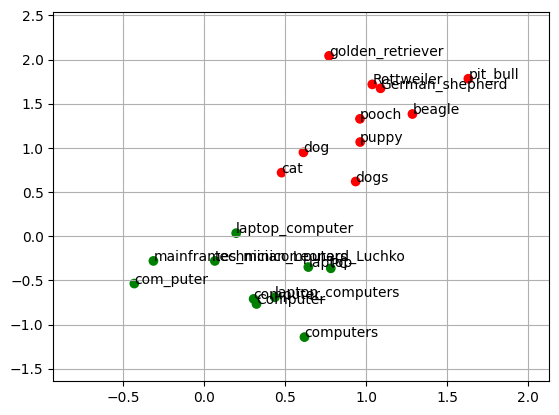

In [100]:
plot_embeddings(w2v_vectors, 
                near_dog + near_computer, 
                pca_model=w2v_pca,
                color=['red'] * len(near_dog) + ['green'] * len(near_computer))

##### Proszę stworzyć własną wizualizację dwóch grup semantycznych

Wybierz dwie grupy po 5-8 słów powiązanych znaczeniowo (np. kolory i kraje, jedzenie i sporty, muzyka i nauka) i wyświetl je na wykresie PCA.

Czy grupy tworzą osobne klastry na wykresie?

In [ ]:
...


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Wzoruj się na komórce powyżej. Stwórz dwie listy słów:
```python
group_a = ['red', 'blue', 'green', 'yellow', 'purple']
group_b = ['france', 'germany', 'italy', 'spain', 'poland']
```
I wywołaj:
```python
plot_embeddings(w2v_vectors, 
                group_a + group_b, 
                color=['red'] * len(group_a) + ['green'] * len(group_b),
                pca_model=w2v_pca)
```

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange']
countries = ['france', 'germany', 'italy', 'spain', 'poland', 'japan']

plot_embeddings(w2v_vectors, 
                colors + countries, 
                pca_model=w2v_pca,
                color=['red'] * len(colors) + ['green'] * len(countries))

######

In [101]:
from collections import namedtuple
import matplotlib.lines as mlines
from matplotlib import cm

LinearSubs = namedtuple('LinearSubs', 
                        ('word_pair', 'name'))

def plot_linear_substructures(linear_subs, embeddings, pca_model=None):
    embeddings_matrix = [embeddings[p] for ls in linear_subs for p in ls.word_pair]
    embeddings_matrix = np.array(embeddings_matrix)
    pair_names = [p for ls in linear_subs for p in ls.word_pair]
    ls_names = [ls.name for ls in linear_subs]
    embeddings_2d = to_2d(embeddings_matrix, pca_model=pca_model)
    annotated_scatter(embeddings_2d, 
                      pair_names, 
                      cm.Set1.colors[:len(embeddings_2d)])
    
    for i in range(0, len(embeddings_2d), 2):
        p1 = embeddings_2d[i]
        p2 = embeddings_2d[i + 1]
        # Center of the linear substructure
        center = [(p1[i] + p2[i]) / 2 + .04 for i in range(2)]
        
        plt.plot(*zip(p1, p2), '--')
        plt.annotate(ls_names[i // 2], 
                     xy=center, 
                     xytext=(0, 0), textcoords='offset points')

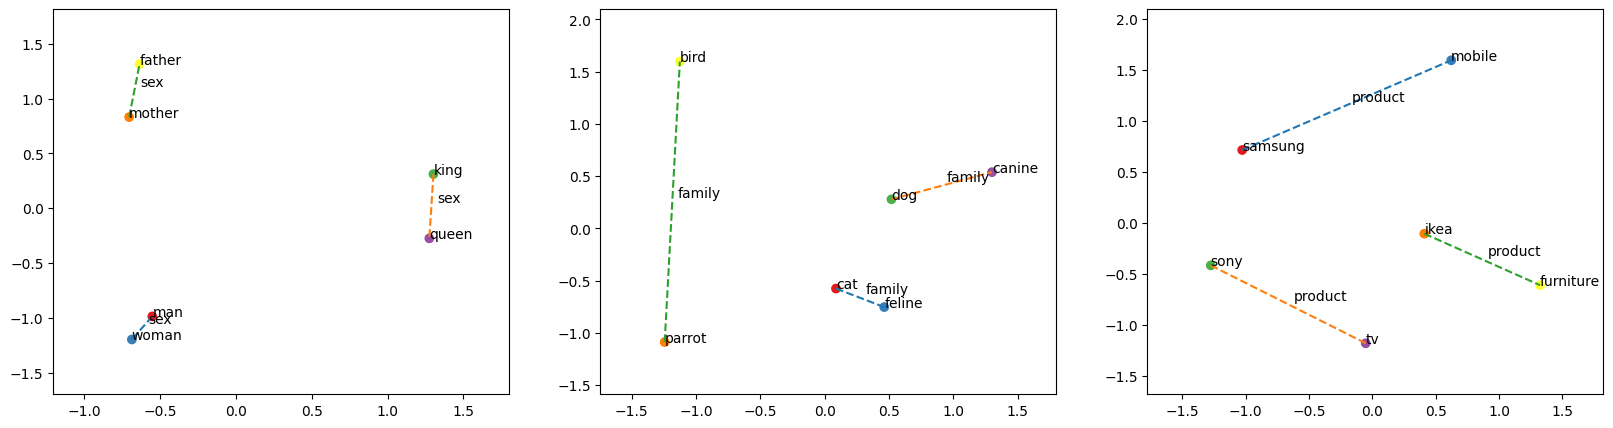

In [102]:
plt.figure(figsize=(20, 5))

plt.subplot(131)
plot_linear_substructures([LinearSubs(('man', 'woman'), 'sex'),
                           LinearSubs(('king', 'queen'), 'sex'),
                           LinearSubs(('mother', 'father'), 'sex')], w2v_vectors, pca_model=w2v_pca)

plt.subplot(132)
plot_linear_substructures([LinearSubs(('cat', 'feline'), 'family'),
                           LinearSubs(('dog', 'canine'), 'family'),
                           LinearSubs(('parrot', 'bird'), 'family')], w2v_vectors, pca_model=w2v_pca)

plt.subplot(133)
plot_linear_substructures([LinearSubs(('samsung', 'mobile'), 'product'),
                           LinearSubs(('sony', 'tv'), 'product'),
                           LinearSubs(('ikea', 'furniture'), 'product')], w2v_vectors)

Powyższe wykresy pokazują **liniowe podstruktury** w embeddingach — jeśli wektor łączący parę (*man*, *woman*) jest równoległy do wektora (*king*, *queen*), to model nauczył się relacji *płci* jako spójnego kierunku w przestrzeni wektorowej. To jest właśnie ta "algebra embeddingów" w akcji.

## GloVe — alternatywa dla Word2Vec

GloVe (Global Vectors for Word Representation) to inna metoda generowania embeddingów, opracowana na Stanfordzie. O ile Word2Vec uczy się z lokalnego kontekstu (okno przesuwne), o tyle GloVe korzysta z **globalnych statystyk współwystępowania** słów w całym korpusie.

Poniżej pobieramy pretrenowane embeddingi GloVe (wymiar 300, korpus 6 miliardów słów) i porównamy je z Word2Vec.

In [ ]:
import os
import zipfile
import urllib.request

glove_file = 'glove.6B.300d.txt'
zip_file = 'glove.6B.zip'
url = 'http://nlp.stanford.edu/data/glove.6B.zip'

if os.path.exists(glove_file):
    print('GloVe 300d już rozpakowane — pomijam pobieranie.')
else:
    if not os.path.exists(zip_file):
        print(f'Pobieram {zip_file} (~862 MB)...')
        urllib.request.urlretrieve(url, zip_file)
        print('Pobrano.')
    print('Rozpakowuję glove.6B.300d.txt...')
    with zipfile.ZipFile(zip_file) as zf:
        zf.extract('glove.6B.300d.txt')
    print('Gotowe.')

print('Wczytuję embeddingi...')
glove_embeddings = {}
with open(glove_file) as f:
    glove_embeddings = {l.split()[0]: np.array(l.split()[1:]).astype('float') for l in f}
print(f'Wczytano {len(glove_embeddings)} słów.')

In [32]:
glove_embeddings['computer']

array([-2.7628e-01,  1.3999e-01,  9.8519e-02, -6.4019e-01,  3.1988e-02,
        1.0066e-01, -1.8673e-01, -3.7129e-01,  5.9740e-01, -2.0405e+00,
        2.2368e-01, -2.6314e-02,  7.2408e-01, -4.3829e-01,  4.8886e-01,
       -3.5486e-03, -1.0006e-01, -3.0587e-01, -1.5621e-01, -6.8136e-02,
        2.1104e-01,  2.9287e-01, -8.8861e-02, -2.0462e-01, -5.7602e-01,
        3.4526e-01,  4.1390e-01,  1.7917e-01,  2.5143e-01, -2.2678e-01,
       -1.0103e-01,  1.4576e-01,  2.0127e-01,  3.1810e-01, -7.8907e-01,
       -2.2194e-01, -2.4833e-01, -1.5103e-02, -2.0050e-01, -2.6441e-02,
        1.8551e-01,  3.3782e-01, -3.3543e-01,  8.6117e-01, -4.7083e-02,
       -1.7009e-01,  3.0438e-01,  9.4119e-02,  3.2435e-01, -8.1171e-01,
        8.8966e-01, -3.9149e-01,  1.6828e-01,  1.4316e-01,  3.6339e-03,
       -6.4557e-02,  4.5777e-02, -3.2248e-01,  4.8943e-02,  1.6817e-01,
        6.8344e-02,  5.4227e-01,  1.2493e-01,  6.9742e-01, -3.7194e-02,
        3.3080e-01, -4.2194e-01,  3.3970e-01,  2.7646e-01, -1.60

In [ ]:
def glove_most_similar(embeddings, positive=None, negative=None, topn=10):
    vec = np.zeros_like(list(embeddings.values())[0])
    query_words = set()
    for w in (positive or []):
        vec = vec + embeddings[w]
        query_words.add(w)
    for w in (negative or []):
        vec = vec - embeddings[w]
        query_words.add(w)

    norms = np.array([np.linalg.norm(v) for v in embeddings.values()])
    dots = np.array([np.dot(vec, v) for v in embeddings.values()])
    sims = dots / (norms * np.linalg.norm(vec) + 1e-10)

    words = list(embeddings.keys())
    ranked = sorted(zip(words, sims), key=lambda x: -x[1])
    return [(w, float(s)) for w, s in ranked if w not in query_words][:topn]

In [ ]:
# PCA dla GloVe — trenujemy na 10k słów
glove_words_10k = list(glove_embeddings.keys())[:10000]
glove_sample = np.array([glove_embeddings[w] for w in glove_words_10k])
glove_pca = PCA(n_components=2, whiten=True)
glove_pca.fit(glove_sample)
print(f'GloVe PCA wytrenowane na {len(glove_sample)} słowach')

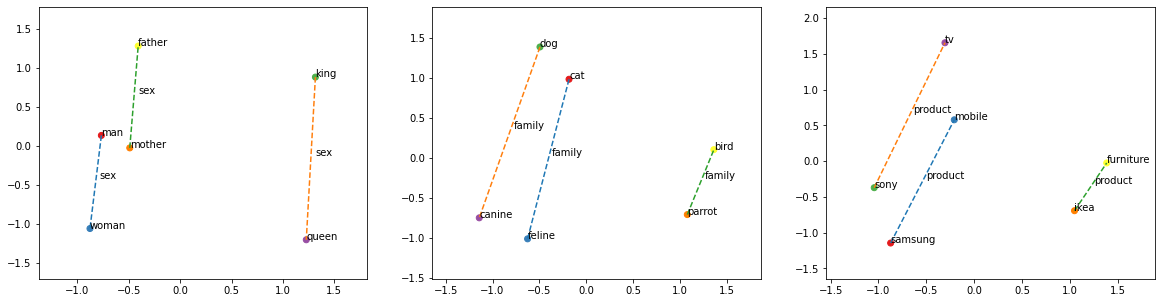

In [34]:
plt.figure(figsize=(20, 5))

plt.subplot(131)
plot_linear_substructures([LinearSubs(('man', 'woman'), 'sex'),
                           LinearSubs(('king', 'queen'), 'sex'),
                           LinearSubs(('mother', 'father'), 'sex')], glove_embeddings, pca_model=glove_pca)

plt.subplot(132)
plot_linear_substructures([LinearSubs(('cat', 'feline'), 'family'),
                           LinearSubs(('dog', 'canine'), 'family'),
                           LinearSubs(('parrot', 'bird'), 'family')], glove_embeddings, pca_model=glove_pca)

plt.subplot(133)
plot_linear_substructures([LinearSubs(('samsung', 'mobile'), 'product'),
                           LinearSubs(('sony', 'tv'), 'product'),
                           LinearSubs(('ikea', 'furniture'), 'product')], glove_embeddings, pca_model=glove_pca)

##### Proszę porównać wyniki Word2Vec i GloVe dla analogii `rome - italy + france = ?`

Użyj odpowiednich funkcji dla obu modeli i porównaj wyniki. Czy oba modele dają ten sam rezultat?

In [ ]:
# Word2Vec:
print("Word2Vec:")
...

# GloVe:
print("\nGloVe:")
...

###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Dla Word2Vec użyj `most_similar()` z parametrami `positive` i `negative`.

Dla GloVe użyj `glove_most_similar()` z tymi samymi parametrami — interfejs jest identyczny.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
# Word2Vec:
print("Word2Vec:")
print(w2v_vectors.most_similar(positive=['france', 'rome'], negative=['italy'], topn=3))

# GloVe:
print("\nGloVe:")
print(glove_most_similar(glove_embeddings, positive=['france', 'rome'], negative=['italy'], topn=3))

######

Oba modele powinny dać `paris` jako najbliższy wynik — co potwierdza, że zarówno Word2Vec jak i GloVe nauczyły się relacji stolica-kraj, choć zostały wytrenowane różnymi metodami.

## Tokenizacja w LLM-ach — BPE

Embeddingi Word2Vec i GloVe operują na **całych słowach**. Współczesne modele językowe (GPT, Gemini, Llama) używają innego podejścia: **Byte Pair Encoding (BPE)**.

BPE dzieli tekst na **subtokeny** — fragmenty słów dobrane statystycznie z korpusu treningowego. Dzięki temu:
- **nie ma słów „nieznanych”** — nawet zupełnie nowe słowo zostanie rozłożone na znane kawałki
- **słownik jest kompaktowy** — GPT-4 ma ~100k tokenów zamiast milionów słów
- **częste słowa** (np. angielskie *the*, *is*) to pojedyncze tokeny
- **rzadkie/długie słowa** (np. polskie *Konstantynopolitańczykowianeczka*) są rozbijane na wiele kawałków

Konsekwencja: **tekst w języku polskim zużywa więcej tokenów** niż ten sam tekst po angielsku — bo tokenizer był trenowany głównie na angielskim korpusie.

In [ ]:
ensure_package('tiktoken')
from utils import show_tokens
from IPython.display import display, HTML

# === Spacje są częścią tokenów ===
display(HTML('<hr><h4>Spacje są częścią tokenów</h4>'))
show_tokens('The witcher drew his silver sword.')

# === Polski vs angielski ===
display(HTML('<h4>Polskie słowa zużywają więcej tokenów</h4>'))
show_tokens('The quick brown fox jumps over the lazy dog.', label='angielski')
show_tokens('Szybki brązowy lis przeskakuje nad leniwym psem.', label='polski')

# === Polskie corner-casy ===
display(HTML('<h4>Polskie corner-casy</h4>'))
show_tokens('Konstantynopolitańczykowianeczka')
show_tokens('Grzegorz Brzęczyszczykiewicz')

# === Liczby ===
display(HTML('<h4>Liczby rozbijane na kawałki</h4>'))
show_tokens('Cena: 12345.67 PLN')
show_tokens('Telefon: +48 123 456 789')

# === Emoji ===
display(HTML('<h4>Emoji i znaki specjalne</h4>'))
show_tokens('Cześć! 🎉🇵🇱')

# === Kod vs proza ===
display(HTML('<h4>Kod vs proza</h4>'))
show_tokens('def hello_world():', label='Python')
show_tokens('{"name": "Jan", "age": 30}', label='JSON')

Chcesz poeksperymentować z różnymi modelami? Interaktywny playground:
[**tiktokenizer.vercel.app**](https://tiktokenizer.vercel.app/) — można przełączać między GPT-4o, GPT-3.5, Llama i innymi.

## Podsumowanie

W tym warsztacie poznaliśmy trzy sposoby reprezentacji tekstu:

1. **Bag of Words / TF-IDF** — proste, interpretowalne, ale nie kodują znaczenia
2. **Word2Vec** — gęste embeddingi uczone z kontekstu lokalnego
3. **GloVe** — gęste embeddingi uczone z globalnych statystyk współwystępowania

Kluczowe wnioski:
- Jakość embeddingów zależy od **rozmiaru danych treningowych** (Brown corpus vs Google News)
- Embeddingi zachowują **relacje semantyczne** — pozwalają na "algebrę słów"
- Pretrenowane modele (transfer learning) zazwyczaj działają lepiej niż trenowane od zera na małych danych

Na następnych zajęciach wykorzystamy te koncepcje do budowy **modelu językowego** — sieci neuronowej, która będzie generować nazwy polskich miast.